# Brain Signal Analysis Pipeline

Complete pipeline for brain signal analysis:
1. MTAD-GAT Anomaly Detection (pre-computed)
2. Segmentation based on anomaly points
3. Connectivity Matrix (CM) computation
4. K-means Clustering with Elbow method
5. BrainLM Training for latent extraction
6. Latent Space Visualization

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import torch
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Check device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

Using device: mps


In [2]:
# Define paths
DATA_PATH = Path('../data/DATA')
RESULT_PATH = Path('../result')
OUTPUT_PATH = Path('../visualization')
CHECKPOINT_PATH = Path('../checkpoint/brainlm')
MTAD_GAT_CHECKPOINT = Path('../checkpoint/global_checkpoint_iter_0.pkl')  # For embedding segmentation
SPLIT_DIR = Path('../data/DATA/data_pre/split_info')

OUTPUT_PATH.mkdir(exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)

print(f"Data path: {DATA_PATH}")
print(f"Result path: {RESULT_PATH}")
print(f"Output path: {OUTPUT_PATH}")

Data path: ../data/DATA
Result path: ../result
Output path: ../visualization


## Phase 2: Segmentation

Segment time series. Choose method via `SEGMENTATION_METHOD`:
- **anomaly**: 정상 구간만 사용 (anomaly 경계에서 분할)
- **anomaly_smooth**: pred_global smoothing 후 분할
- **embedding**: latent embedding 변화량 peak 기반 (transition 지향)

In [3]:
# Segmentation method: "anomaly" | "anomaly_smooth" | "embedding"
# - anomaly: 정상 구간만 사용 (anomaly 경계에서 분할)
# - anomaly_smooth: pred_global smoothing 후 anomaly 기반 분할
# - embedding: latent embedding 변화량 peak 기반 (transition 지향)
SEGMENTATION_METHOD = "embedding"

In [ ]:
from pipeline.segmentation import segment_all_subjects, get_segment_statistics

# Fallback if path cell wasn't run
try:
    SPLIT_DIR
except NameError:
    SPLIT_DIR = Path('../data/DATA/data_pre/split_info')

if SEGMENTATION_METHOD == "embedding":
    from pipeline.segmentation_evaluation import segment_all_subjects_embedding
    print(f"Segmenting with method: {SEGMENTATION_METHOD} (embedding change-based, transition-oriented)")
    all_segments = segment_all_subjects_embedding(
        data_path=DATA_PATH,
        checkpoint_path=MTAD_GAT_CHECKPOINT,
        min_segment_len=30,
        window_size=64,
        split_dir=SPLIT_DIR,
        top_k=20,
        smooth_window=5,
        device=device,
        data_pre_path=SPLIT_DIR.parent,
        verbose=True,
    )
else:
    print(f"Segmenting with method: {SEGMENTATION_METHOD}...")
    all_segments = segment_all_subjects(
        data_path=DATA_PATH,
        result_path=RESULT_PATH,
        min_segment_len=30,
        window_size=64,
        split_dir=SPLIT_DIR,
        method=SEGMENTATION_METHOD,
        smooth_window=5,
    )

# Get statistics
segment_stats = get_segment_statistics(all_segments)
print(f"\nTotal segments: {len(segment_stats)}")
print(f"Subjects processed: {segment_stats['subject_id'].nunique()}")
print(f"Average segment length: {segment_stats['length'].mean():.2f}")
print(f"Segments per subject: {segment_stats.groupby('subject_id').size().mean():.2f}")

Segmenting with method: embedding (embedding change-based, transition-oriented)


Embedding segmentation:   4%|▎         | 1/27 [00:05<02:17,  5.28s/it]

Subject 108828: 14 segments


Embedding segmentation:   7%|▋         | 2/27 [00:10<02:07,  5.10s/it]

Subject 113316: 12 segments


...

Subject 105014: 13 segments


Embedding segmentation:  67%|██████▋   | 18/27 [01:30<00:45,  5.00s/it]

Subject 120111: 8 segments


Embedding segmentation:  70%|███████   | 19/27 [01:35<00:40,  5.00s/it]

Subject 117122: 11 segments


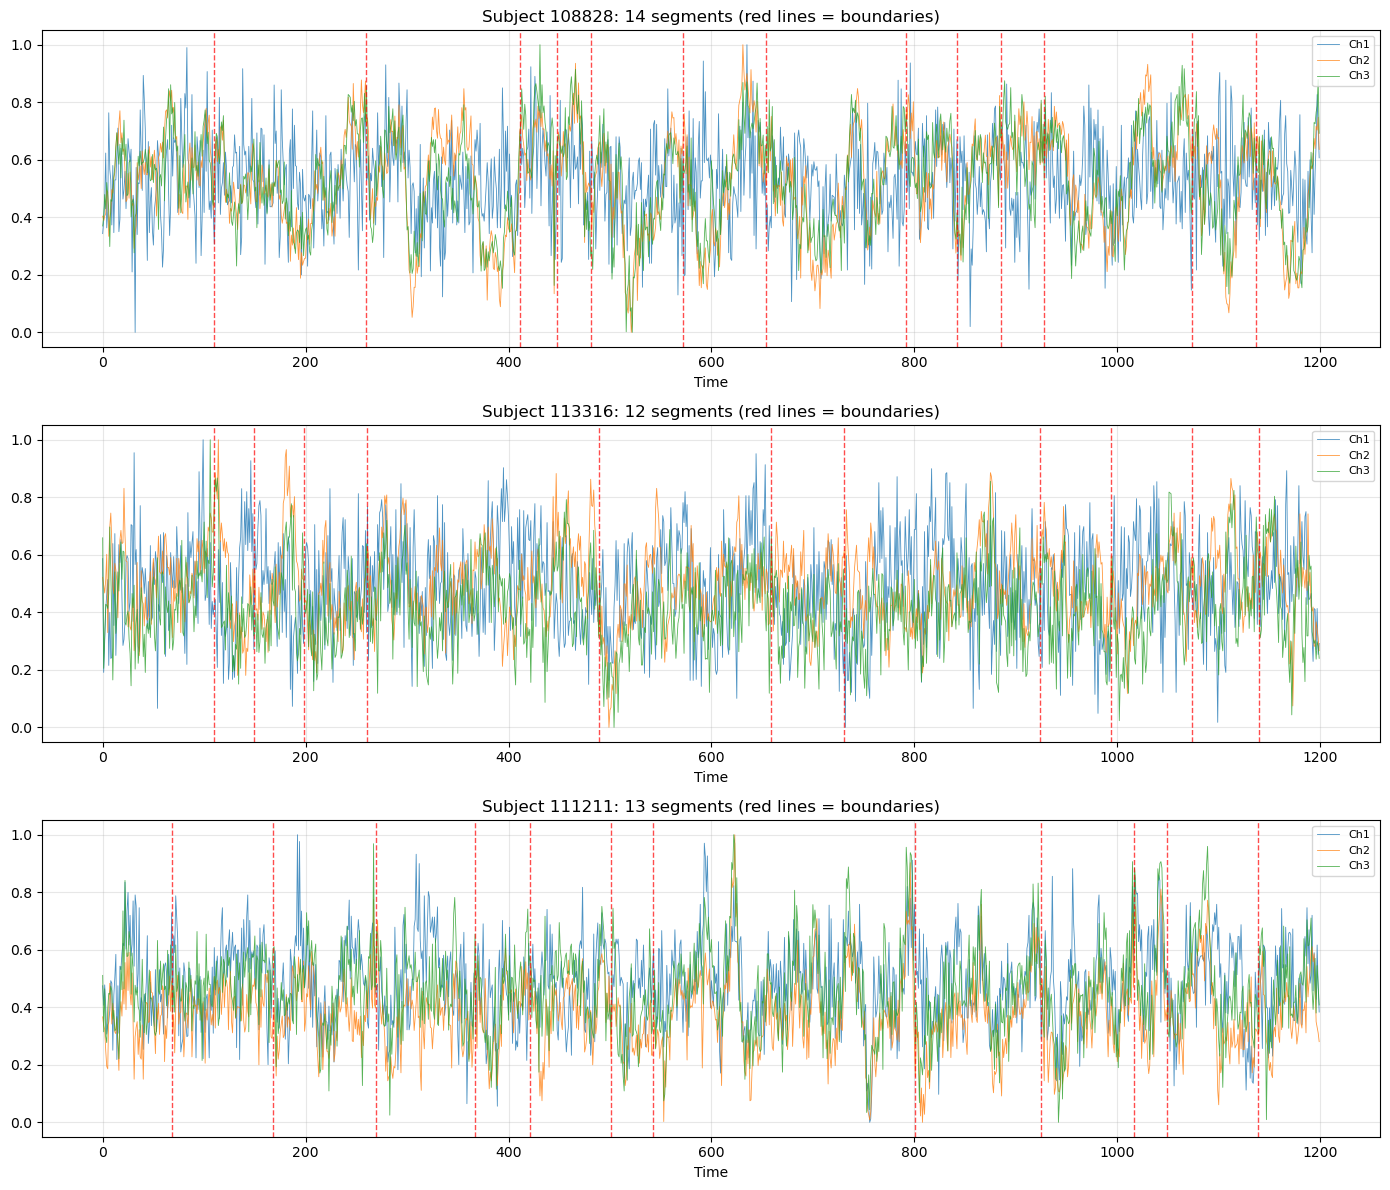

In [ ]:
# Visualize sample segments: full timeseries with boundaries
import matplotlib.pyplot as plt

N_VISUALIZE = 3  # number of subjects to visualize
N_FEATURES_SHOW = 3  # plot first N channels

data_pre = DATA_PATH / "data_pre" if (DATA_PATH / "data_pre").exists() else SPLIT_DIR.parent
subject_ids = list(all_segments.keys())[:N_VISUALIZE]
fig, axes = plt.subplots(len(subject_ids), 1, figsize=(14, 4 * len(subject_ids)), squeeze=False)
axes = axes[:, 0]

for ax_idx, sid in enumerate(subject_ids):
    segs = all_segments[sid]
    if not segs:
        axes[ax_idx].set_title(f"Subject {sid}: No segments")
        continue

    # Load full original timeseries
    test_path = data_pre / f"test_{sid}.csv"
    if test_path.exists():
        full_data = pd.read_csv(test_path, header=0).values.astype(np.float32)
    else:
        full_data = np.concatenate([s.data for s in segs], axis=0)

    T, n_feat = full_data.shape
    n_plot = min(N_FEATURES_SHOW, n_feat)
    boundaries = [s.start_idx for s in segs[1:]]  # segment start indices (skip first)

    for f in range(n_plot):
        axes[ax_idx].plot(full_data[:, f], alpha=0.8, linewidth=0.6, label=f"Ch{f+1}")
    for b in boundaries:
        axes[ax_idx].axvline(b, color='red', linestyle='--', alpha=0.7, linewidth=1)
    axes[ax_idx].set_title(f"Subject {sid}: {len(segs)} segments (red lines = boundaries)")
    axes[ax_idx].set_xlabel("Time")
    axes[ax_idx].legend(loc='upper right', fontsize=8)
    axes[ax_idx].grid(True, alpha=0.3)

plt.tight_layout()
OUTPUT_PATH.mkdir(exist_ok=True)
plt.savefig(OUTPUT_PATH / 'segment_samples.png', dpi=150)
plt.show()

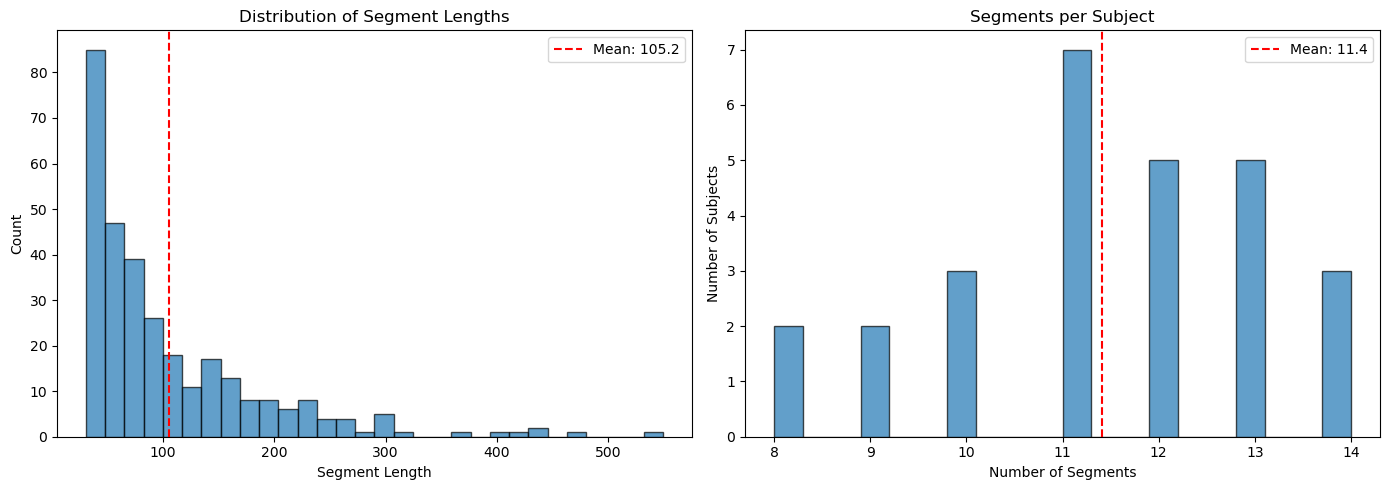

In [ ]:
# Visualize segment length distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment length distribution
axes[0].hist(segment_stats['length'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Segment Length')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Segment Lengths')
axes[0].axvline(segment_stats['length'].mean(), color='r', linestyle='--', label=f'Mean: {segment_stats["length"].mean():.1f}')
axes[0].legend()

# Segments per subject
segments_per_subject = segment_stats.groupby('subject_id').size()
axes[1].hist(segments_per_subject.values, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Segments')
axes[1].set_ylabel('Number of Subjects')
axes[1].set_title('Segments per Subject')
axes[1].axvline(segments_per_subject.mean(), color='r', linestyle='--', label=f'Mean: {segments_per_subject.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'segment_statistics.png', dpi=150)
plt.show()

## Phase 3: Connectivity Matrix Computation

Compute Pearson correlation-based connectivity matrices for each segment.

In [ ]:
from pipeline.connectivity import compute_all_cms, collect_all_cms_flat, compute_subject_average_cm

# Compute CMs for all segments
print("Computing connectivity matrices...")
all_cms = compute_all_cms(all_segments, method='pearson', min_segment_len=10)

# Collect all CMs into a matrix for clustering
X, cm_labels = collect_all_cms_flat(all_cms)
print(f"\nTotal CMs: {len(cm_labels)}")
print(f"Feature dimension: {X.shape[1]}")

Computing connectivity matrices...
Subject 108828: 14 CMs computed
Subject 113316: 12 CMs computed
Subject 111211: 13 CMs computed
Subject 119025: 11 CMs computed
Subject 113215: 10 CMs computed
Subject 107018: 9 CMs computed
Subject 120717: 13 CMs computed
Subject 113619: 11 CMs computed
Subject 114419: 11 CMs computed
Subject 120515: 12 CMs computed
Subject 108121: 12 CMs computed
Subject 106319: 9 CMs computed
Subject 100307: 14 CMs computed
Subject 111716: 12 CMs computed
Subject 104416: 13 CMs computed
Subject 100408: 13 CMs computed
Subject 105014: 13 CMs computed
Subject 120111: 8 CMs computed
Subject 117122: 11 CMs computed
Subject 119732: 14 CMs computed
Subject 118831: 10 CMs computed
Subject 103818: 11 CMs computed
Subject 113922: 12 CMs computed
Subject 116524: 10 CMs computed
Subject 102816: 11 CMs computed
Subject 121416: 8 CMs computed
Subject 111514: 11 CMs computed

Total CMs: 308
Feature dimension: 4950


Visualizing CMs from subject 108828


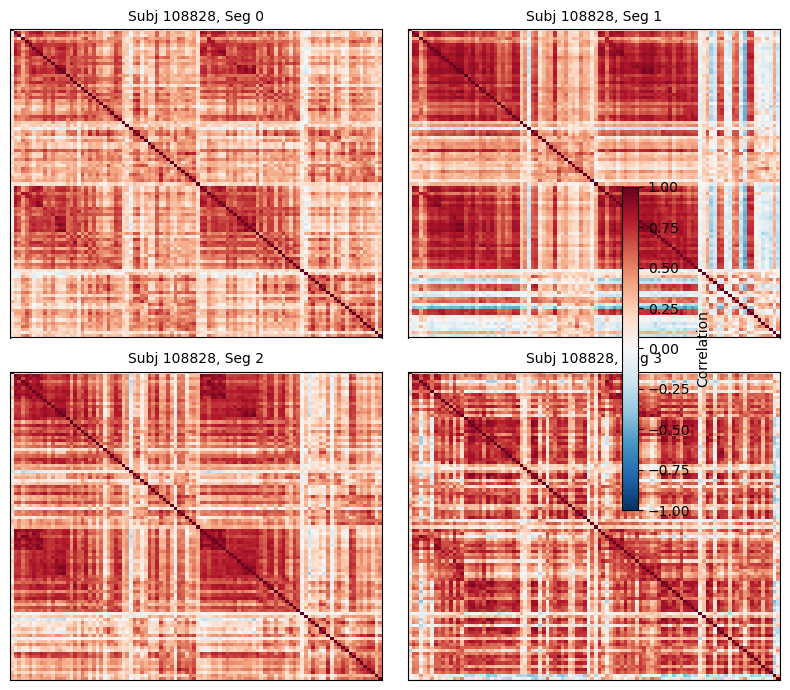

: 

In [ ]:
from pipeline.visualization import plot_cm_heatmap, plot_multiple_cms



# Visualize example CMs
example_subject = list(all_cms.keys())[0]
example_cms = all_cms[example_subject][:4]

print(f"Visualizing CMs from subject {example_subject}")
fig = plot_multiple_cms(example_cms, n_cols=2, show=True)
fig.savefig(OUTPUT_PATH / 'example_cms.png', dpi=150)

## Phase 4: K-means Clustering

Cluster CMs using K-means with optimal K determined by Elbow method.

In [ ]:
from pipeline.clustering import find_optimal_k, perform_clustering, get_cluster_centroids, compute_cluster_similarity
from pipeline.visualization import plot_elbow_curve, plot_cluster_centroids, plot_similarity_matrix, plot_cluster_distribution

# Find optimal K (kernel crash 방지: use_minibatch, skip_silhouette, n_init=1)
print("Finding optimal number of clusters...")
optimal_k, metrics = find_optimal_k(
    X, k_range=range(2, 10),
    method='elbow',
    n_init=1,
    skip_silhouette=True,
    use_minibatch=True,  # MiniBatchKMeans 사용 (메모리 절약)
)
print(f"Optimal K: {optimal_k}")

# Plot elbow curve
fig = plot_elbow_curve(metrics, show=True)
fig.savefig(OUTPUT_PATH / 'elbow_curve.png', dpi=150)

In [ ]:
#optimal_k = 5 
# Perform clustering (skip_silhouette=True if kernel crashes)
print(f"\nPerforming K-means clustering with K={optimal_k}...")
clustering_result = perform_clustering(
    X, cm_labels, n_clusters=optimal_k,
    n_init=3, skip_silhouette=True,  # kernel crash 방지
)

print(f"Silhouette score: {clustering_result.silhouette:.4f}")
print(f"Cluster sizes: {clustering_result.get_cluster_sizes()}")

# Plot cluster distribution
fig = plot_cluster_distribution(clustering_result, show=True)
fig.savefig(OUTPUT_PATH / 'cluster_distribution.png', dpi=150)


Performing K-means clustering with K=5...


NameError: name 'perform_clustering' is not defined

In [ ]:
# Get and visualize cluster centroids
centroids = get_cluster_centroids(clustering_result, n_features=100)
fig = plot_cluster_centroids(centroids, show=True)
fig.savefig(OUTPUT_PATH / 'cluster_centroids.png', dpi=150)

In [ ]:
# Compute similarity between individual CMs and cluster centroids
print("Computing subject-cluster similarities...")
similarities = compute_cluster_similarity(all_cms, clustering_result, n_features=100)

# Plot similarity matrix
fig = plot_similarity_matrix(similarities, show=True)
fig.savefig(OUTPUT_PATH / 'subject_cluster_similarity.png', dpi=150)

## Phase 5: BrainLM Training

Train BrainLM model on CM data to extract latent representations.

In [ ]:
from brainlm.model import BrainLM, BrainLMConfig
from brainlm.dataset import BrainLMDataset, create_dataloaders
from brainlm.train import train_brainlm, extract_latents

# Collect all CMs as a list
all_cms_list = []
for subject_id, cms in all_cms.items():
    all_cms_list.extend(cms)

print(f"Total CMs for training: {len(all_cms_list)}")

In [ ]:
# Create dataloaders
train_loader, val_loader, test_loader = create_dataloaders(
    cms=all_cms_list,
    cluster_labels=clustering_result.labels,
    batch_size=32,
    val_split=0.1,
    test_split=0.1,
    mask_ratio=0.15
)

print(f"Train samples: {len(train_loader.dataset)}")
print(f"Val samples: {len(val_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")

In [ ]:
# Configure BrainLM model
config = BrainLMConfig(
    n_features=100,
    d_model=256,
    nhead=8,
    num_encoder_layers=4,
    num_decoder_layers=2,
    dim_feedforward=1024,
    dropout=0.1,
    max_seq_len=64,
    mask_ratio=0.15
)

print(f"Input dimension: {config.input_dim}")
print(f"Model dimension: {config.d_model}")

In [ ]:
# Train BrainLM
print("Training BrainLM...")
model, history = train_brainlm(
    train_loader=train_loader,
    val_loader=val_loader,
    config=config,
    max_epochs=50,
    lr=1e-4,
    patience=10,
    checkpoint_dir=CHECKPOINT_PATH,
    device=device
)

print(f"\nTraining complete!")
print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss: {history['val_loss'][-1]:.4f}")

In [ ]:
from pipeline.visualization import plot_training_history

# Plot training history
fig = plot_training_history(history, show=True)
fig.savefig(OUTPUT_PATH / 'brainlm_training_history.png', dpi=150)

## Phase 6: Latent Space Visualization

Extract and visualize latent representations from BrainLM.

In [ ]:
# Create dataloader for all data (for latent extraction)
from torch.utils.data import DataLoader

all_dataset = BrainLMDataset(
    cms=all_cms_list,
    cluster_labels=clustering_result.labels,
    mask_ratio=0,
    augment=False
)

all_loader = DataLoader(all_dataset, batch_size=64, shuffle=False)
print(f"Total samples for latent extraction: {len(all_dataset)}")

In [ ]:
# Extract latents
print("Extracting latent representations...")
latents, cluster_ids = extract_latents(model, all_loader, device)
print(f"Latent shape: {latents.shape}")
print(f"Unique clusters: {np.unique(cluster_ids)}")

In [ ]:
from pipeline.visualization import visualize_latents, visualize_latents_3d

# t-SNE visualization
fig = visualize_latents(
    latents, cluster_ids,
    method='tsne',
    perplexity=30,
    title='BrainLM Latent Space (t-SNE)',
    show=True
)
fig.savefig(OUTPUT_PATH / 'latent_tsne.png', dpi=150)

In [ ]:
# PCA visualization
fig = visualize_latents(
    latents, cluster_ids,
    method='pca',
    title='BrainLM Latent Space (PCA)',
    show=True
)
fig.savefig(OUTPUT_PATH / 'latent_pca.png', dpi=150)

In [ ]:
# 3D visualization
fig = visualize_latents_3d(
    latents, cluster_ids,
    method='pca',
    title='BrainLM Latent Space (3D PCA)',
    show=True
)
fig.savefig(OUTPUT_PATH / 'latent_3d_pca.png', dpi=150)

## Summary

Save all results and generate summary report.

In [ ]:
import json

# Save latents and cluster assignments
np.save(OUTPUT_PATH / 'latents.npy', latents)
np.save(OUTPUT_PATH / 'cluster_ids.npy', cluster_ids)

# Save summary
summary = {
    'n_subjects': len(all_segments),
    'n_segments': len(segment_stats),
    'n_cms': len(all_cms_list),
    'n_clusters': optimal_k,
    'silhouette_score': float(clustering_result.silhouette),
    'cluster_sizes': {int(k): int(v) for k, v in clustering_result.get_cluster_sizes().items()},
    'latent_dim': int(latents.shape[1]),
    'final_train_loss': float(history['train_loss'][-1]),
    'final_val_loss': float(history['val_loss'][-1])
}

with open(OUTPUT_PATH / 'pipeline_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*50)
print("PIPELINE SUMMARY")
print("="*50)
for key, value in summary.items():
    print(f"{key}: {value}")
print("="*50)
print(f"\nAll results saved to: {OUTPUT_PATH}")

In [ ]:
# List output files
print("\nGenerated files:")
for f in sorted(OUTPUT_PATH.glob('*')):
    print(f"  - {f.name}")